## Importação e configuração do ambiente

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)

data_path = Path.cwd() / '/content/data.csv'
df = pd.read_csv(data_path)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## Análise exploratória dos dados

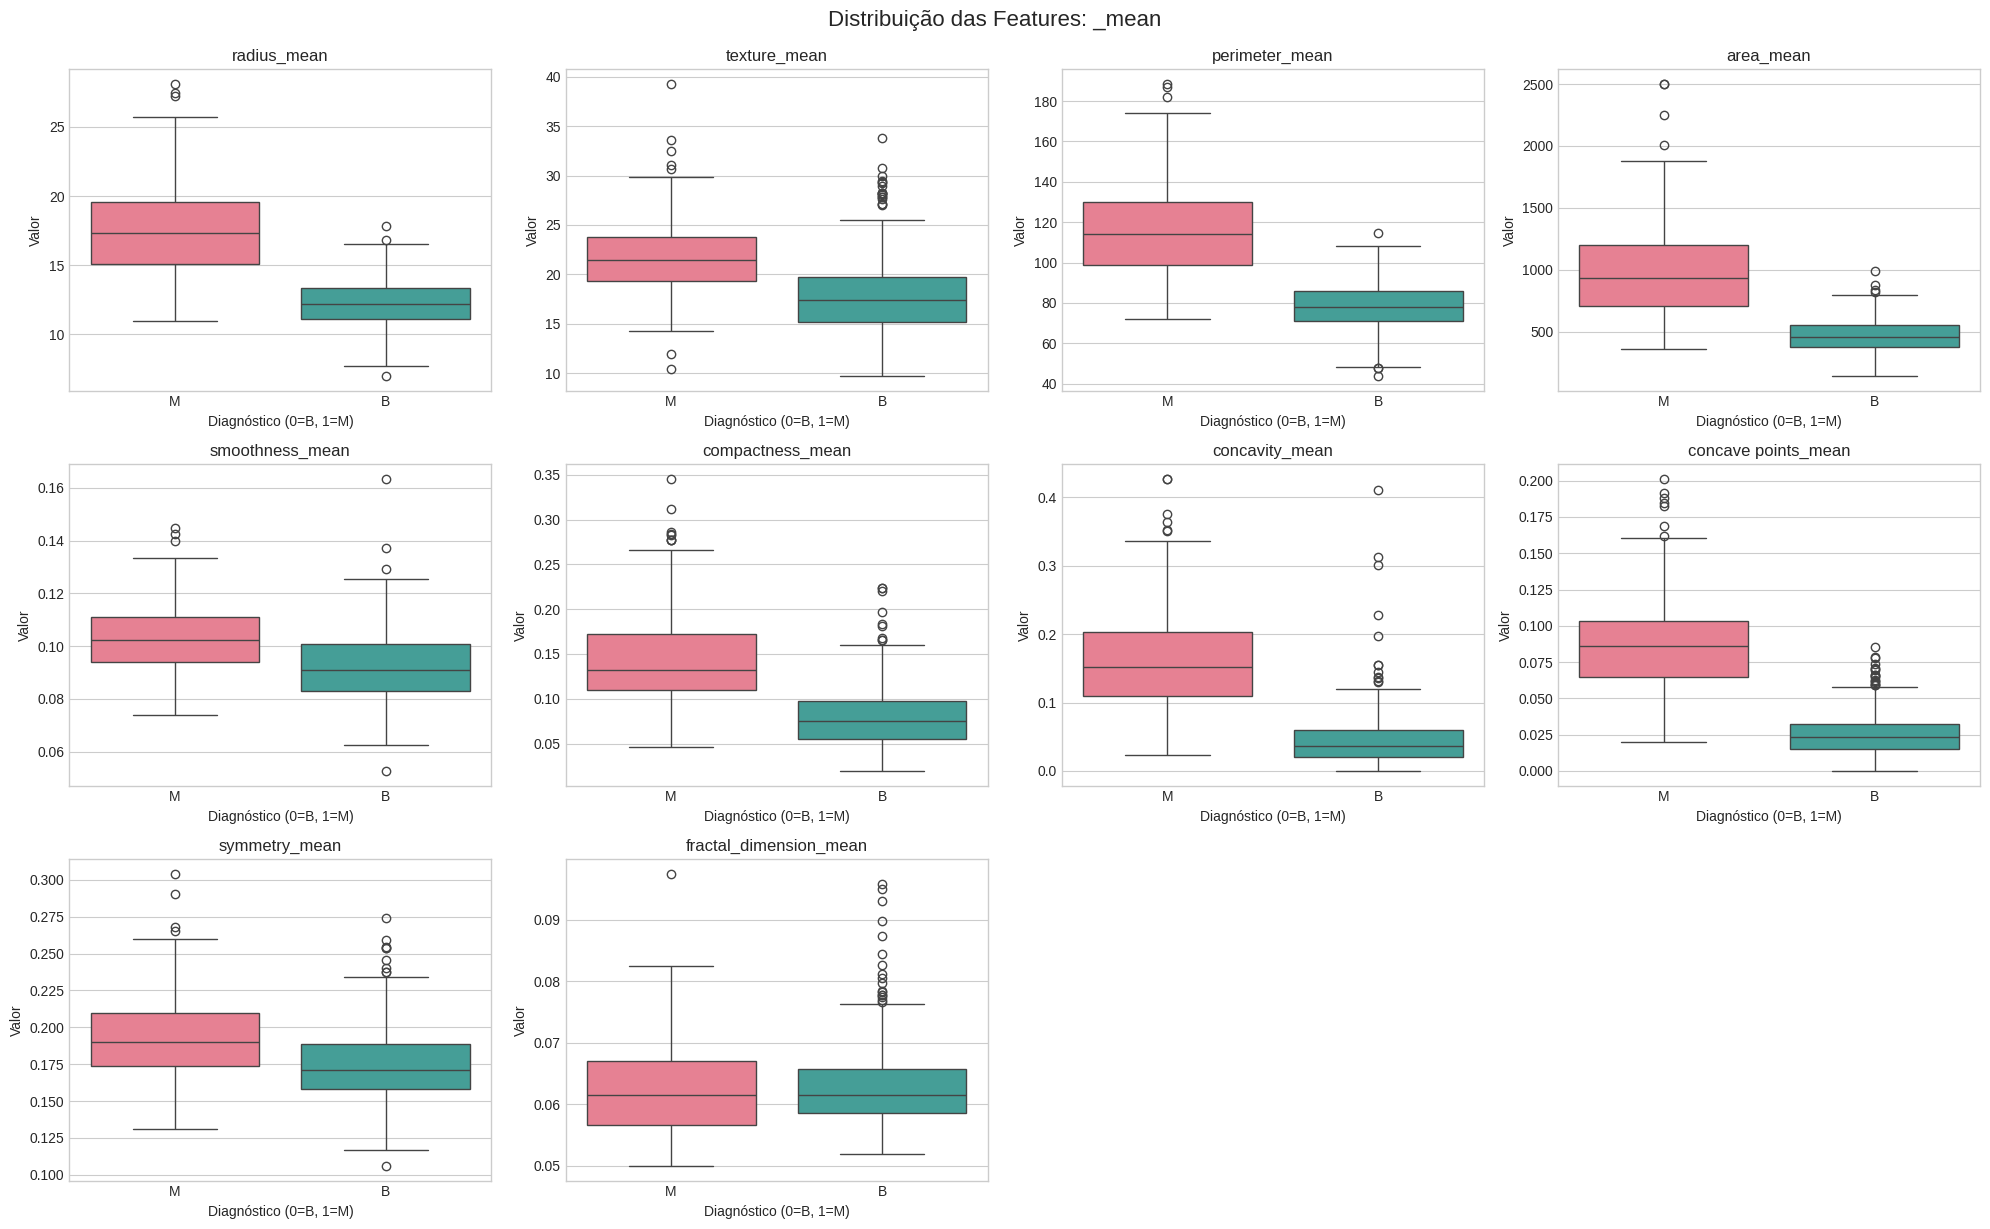

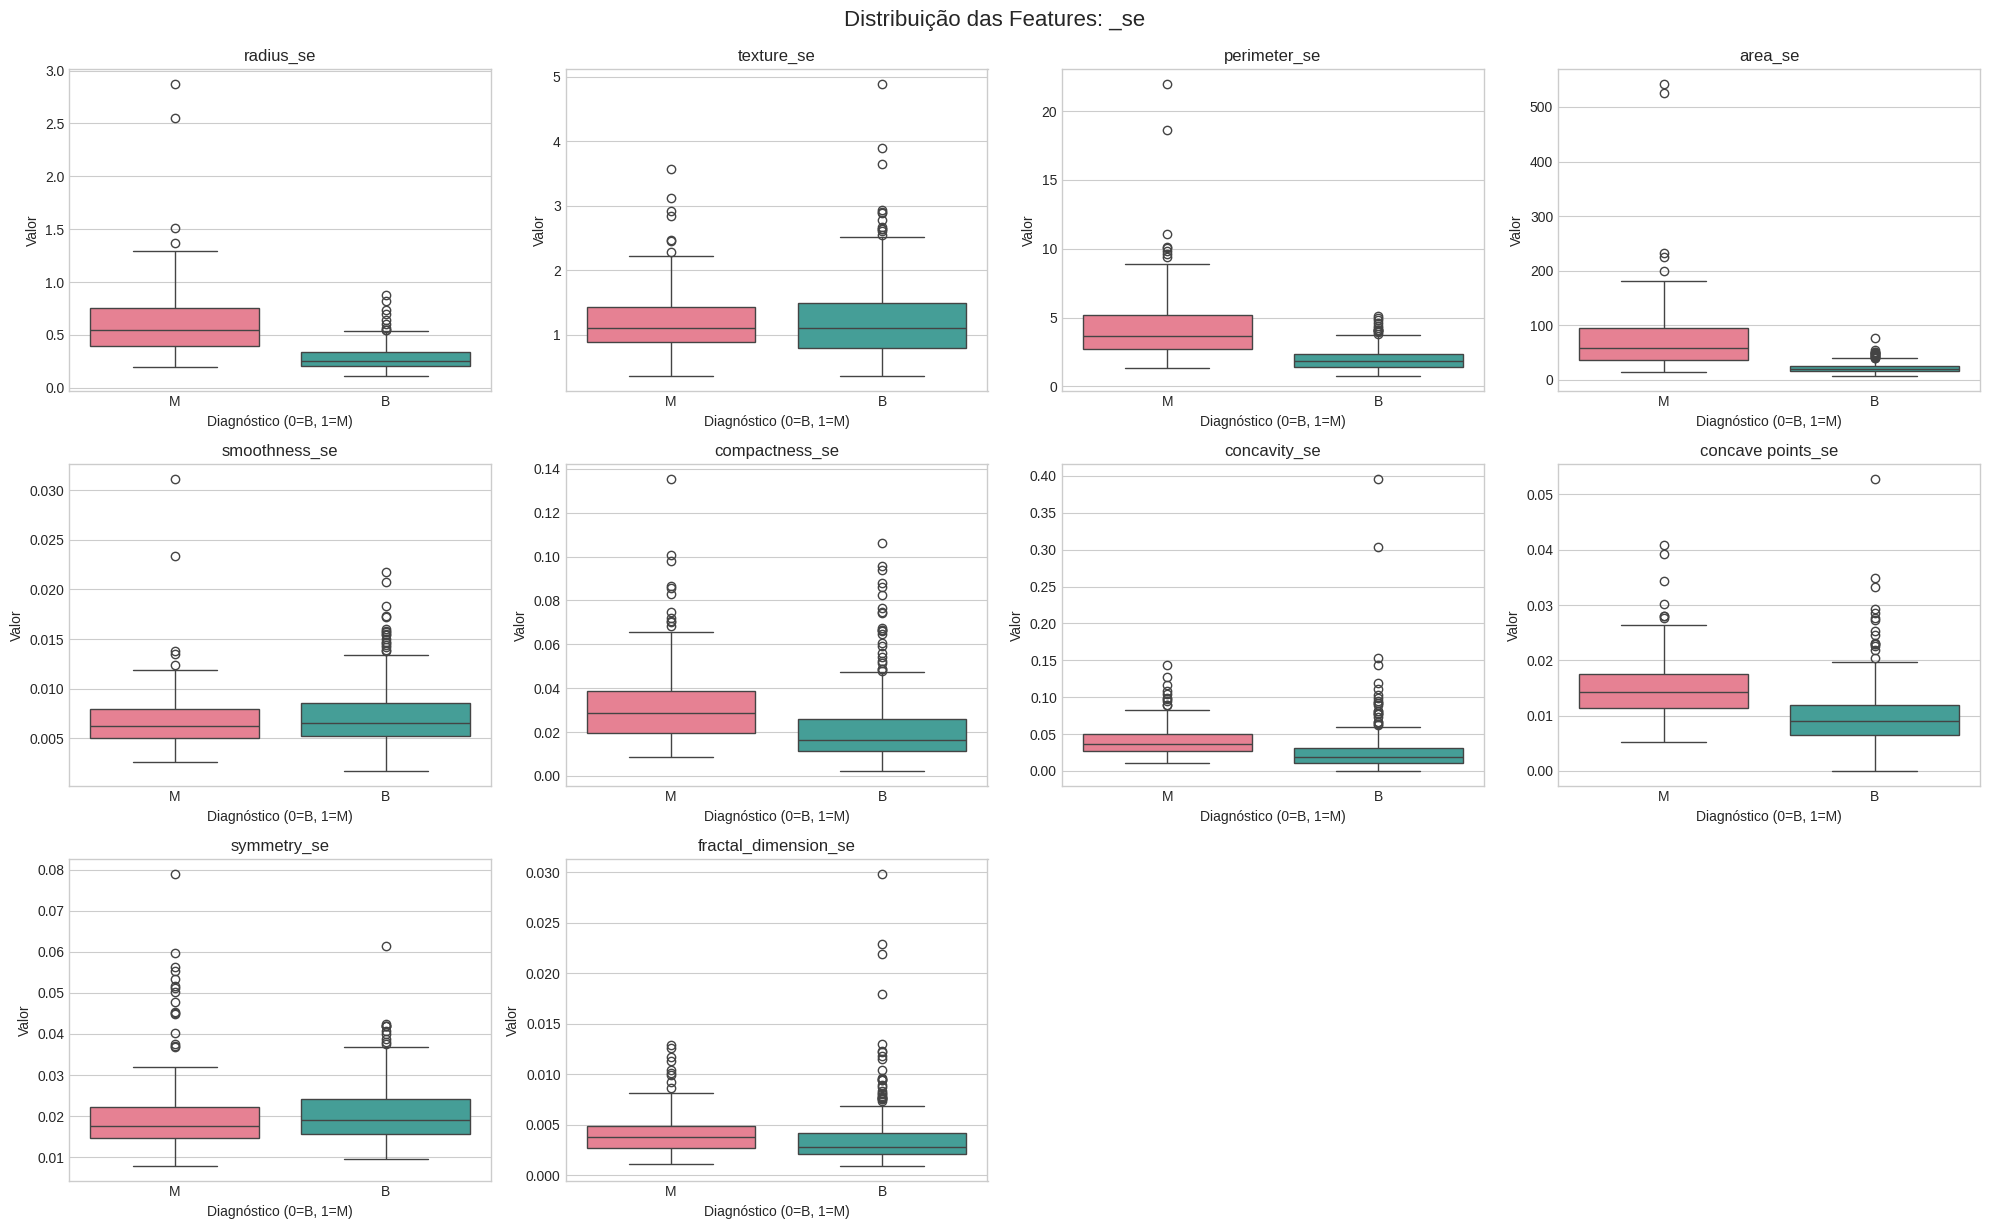

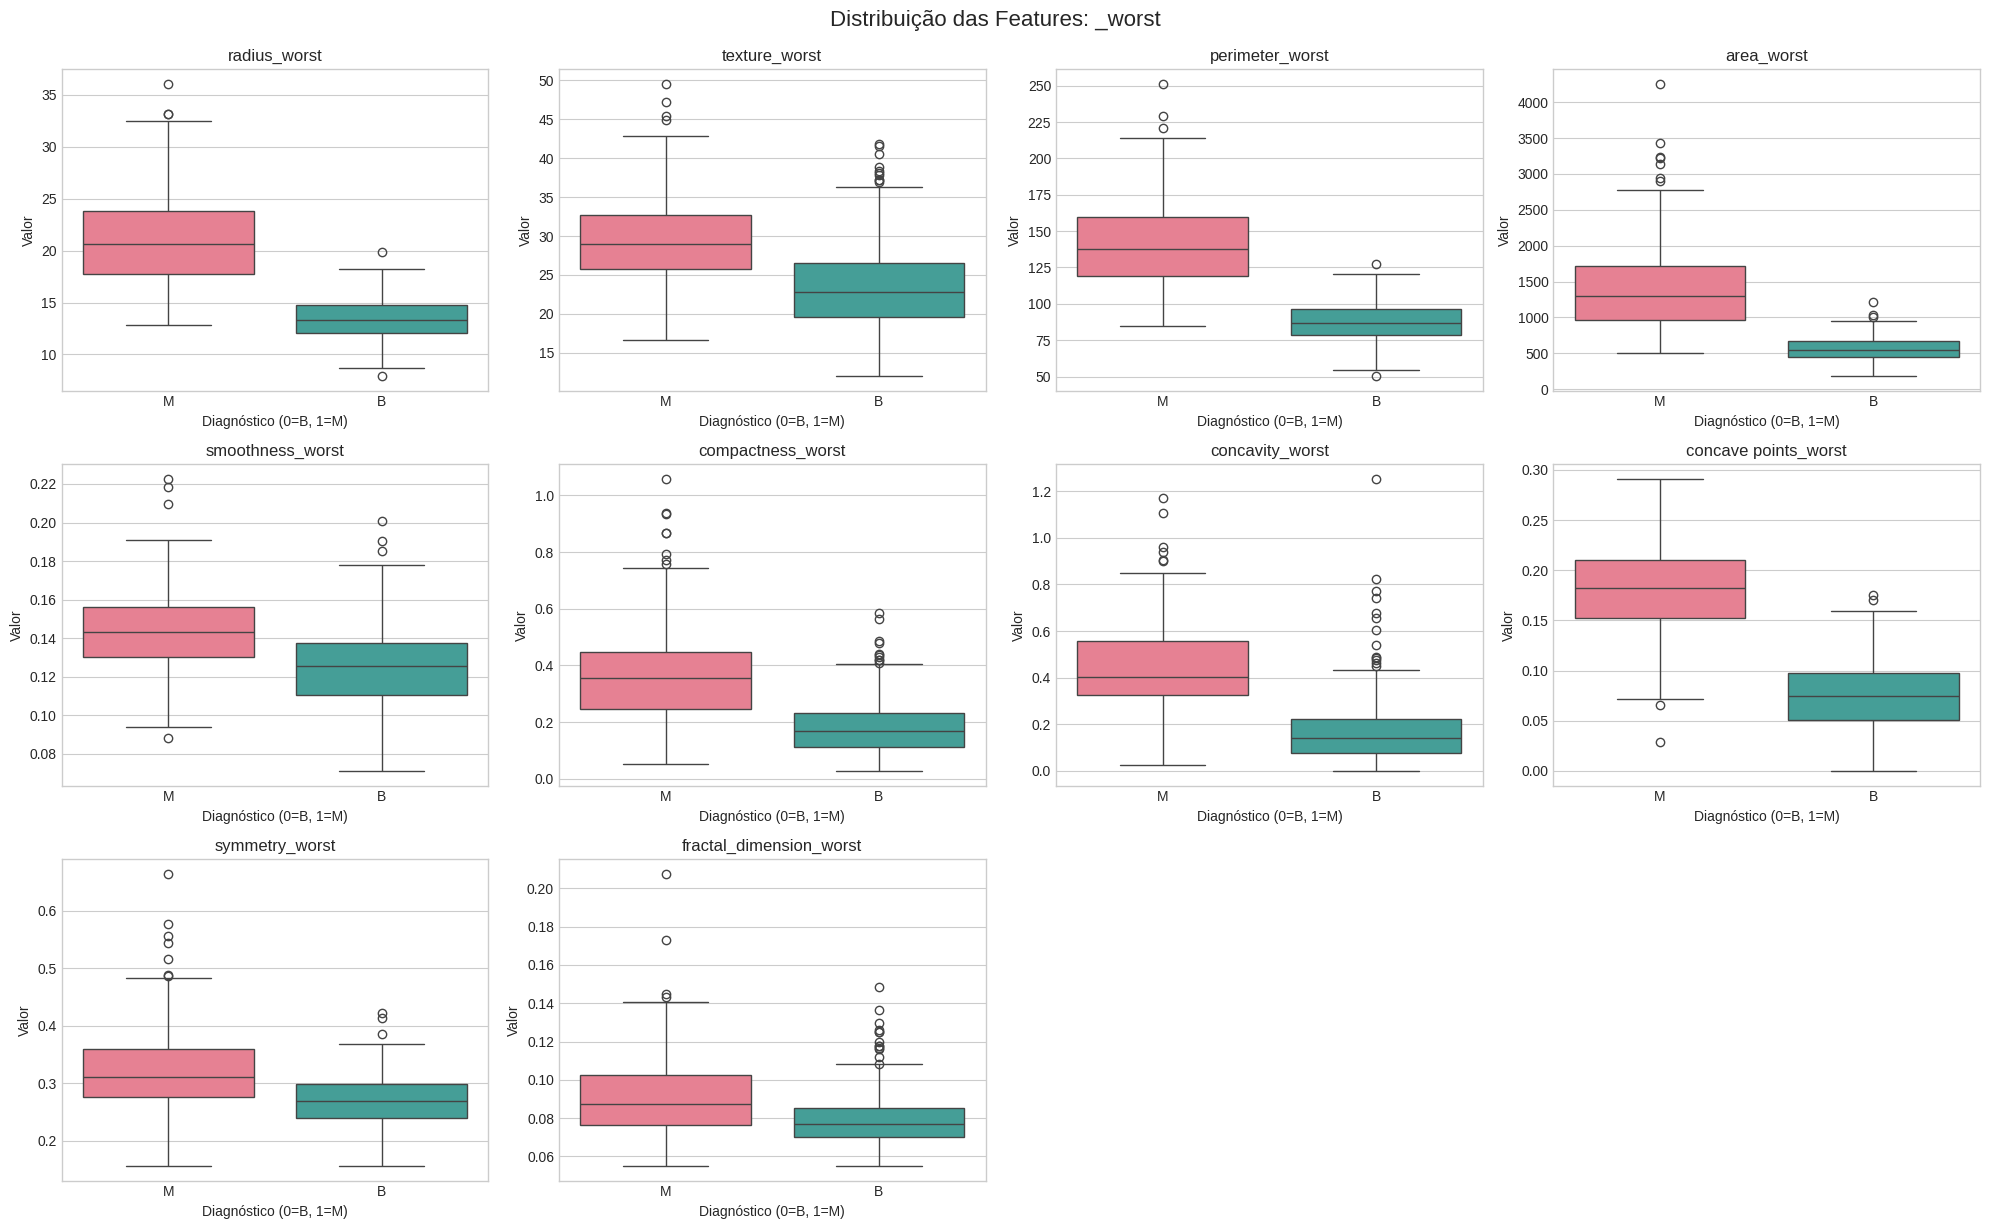

In [ ]:
# Boxplots

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Selecionar todas as colunas numéricas (exceto id e diagnosis)
# O dataset contém sufixos _mean, _se e _worst
features_all = [col for col in df.columns if col not in ['diagnosis', 'id', 'Unnamed: 32']]

# 1. Estatística Descritiva completa
desc_stats = df[features_all + ['diagnosis']].groupby('diagnosis').describe().T
desc_stats.to_csv('all_features_stats.csv')

# 2. Boxplots para todas as features
groups = ['_mean', '_se', '_worst']

for suffix in groups:
    cols = [c for c in features_all if c.endswith(suffix)]
    num_cols = len(cols)
    rows = (num_cols // 4) + (1 if num_cols % 4 != 0 else 0)

    plt.figure(figsize=(20, rows * 4))
    for i, feature in enumerate(cols):
        plt.subplot(rows, 4, i + 1)
        sns.boxplot(x='diagnosis', y=feature, hue='diagnosis', data=df, palette='husl', legend=False)
        plt.title(f'{feature}')
        plt.xlabel('Diagnóstico (0=B, 1=M)')
        plt.ylabel('Valor')

    plt.tight_layout()
    plt.suptitle(f'Distribuição das Features: {suffix}', fontsize=16, y=1.02)
    plt.show()

--- Resumo de Valores Faltantes ---
             Total Faltantes  Porcentagem (%)
Unnamed: 32              569            100.0 



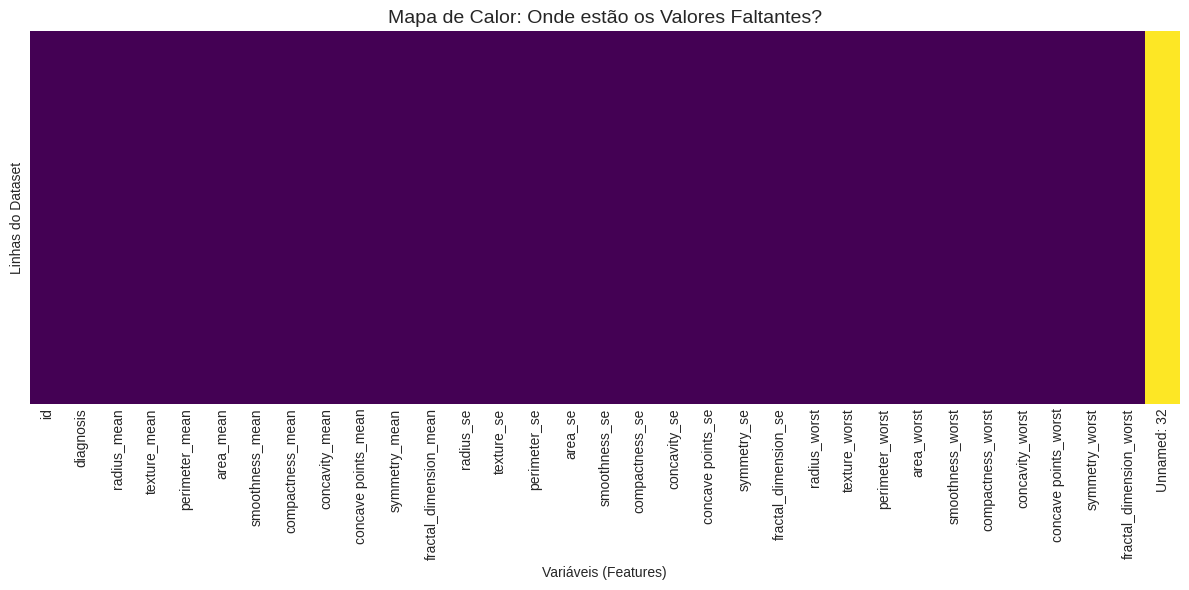

In [ ]:
# ANÁLISE DE VALORES FALTANTES (MISSING VALUES)

# Calcular a quantidade e a porcentagem de dados nulos
total_nulos = df.isnull().sum()
porcentagem_nulos = (df.isnull().sum() / len(df)) * 100
tabela_nulos = pd.concat([total_nulos, porcentagem_nulos], axis=1, keys=['Total Faltantes', 'Porcentagem (%)'])
tabela_nulos = tabela_nulos[tabela_nulos['Total Faltantes'] > 0].sort_values(by='Total Faltantes', ascending=False)

print("--- Resumo de Valores Faltantes ---")
if tabela_nulos.empty:
    print("Ótima notícia: O dataset não possui nenhum valor faltante!\n")
else:
    print(tabela_nulos, "\n")

# Gráfico: Mapa de Calor (Heatmap) de Valores Faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor: Onde estão os Valores Faltantes?', fontsize=14)
plt.xlabel('Variáveis (Features)')
plt.ylabel('Linhas do Dataset')
plt.tight_layout()
plt.show()

--- Resumo de Duplicatas ---
Total de linhas únicas: 569
Total de linhas duplicadas: 0



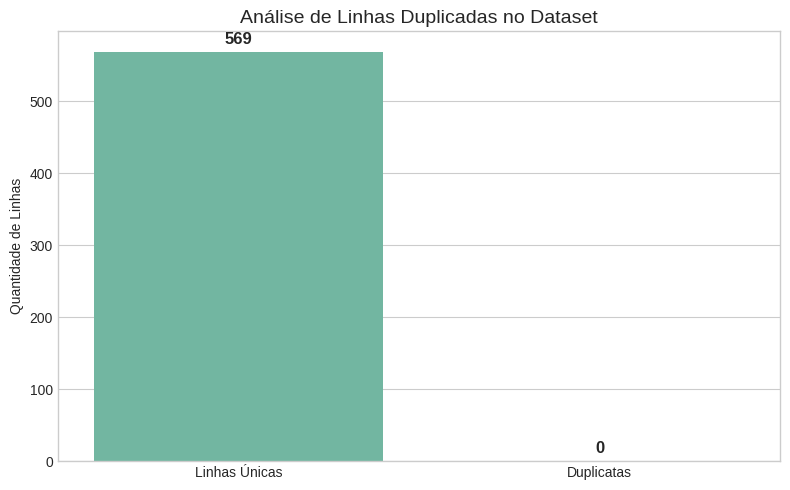

In [ ]:
# ANÁLISE DE LINHAS DUPLICADAS

# Calcular quantidade de duplicatas
duplicatas = df.duplicated().sum()
unicos = len(df) - duplicatas

print("--- Resumo de Duplicatas ---")
print(f"Total de linhas únicas: {unicos}")
print(f"Total de linhas duplicadas: {duplicatas}\n")

# Gráfico: Gráfico de Barras para Duplicatas
plt.figure(figsize=(8, 5))
cores = sns.color_palette("Set2")
ax = sns.barplot(x=['Linhas Únicas', 'Duplicatas'], y=[unicos, duplicatas], palette=[cores[0], cores[3]])

plt.title('Análise de Linhas Duplicadas no Dataset', fontsize=14)
plt.ylabel('Quantidade de Linhas')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

### Distribuição da variável alvo

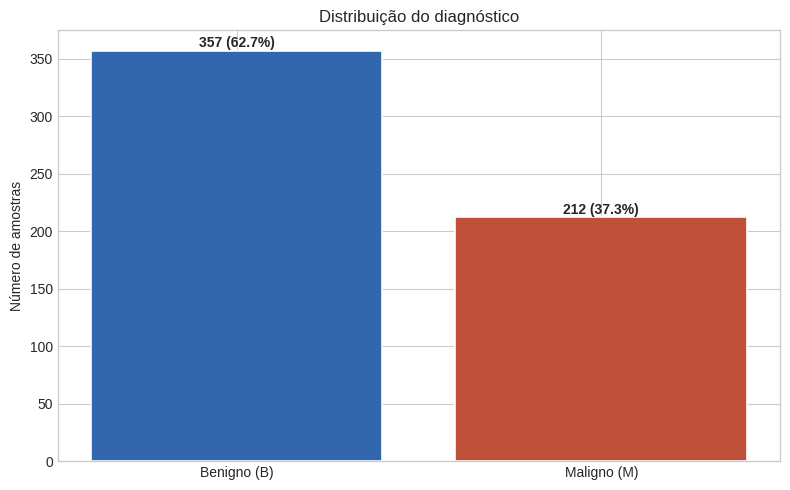

In [ ]:
counts = df['diagnosis'].value_counts()
labels = ['Benigno (B)', 'Maligno (M)']
values = [counts['B'], counts['M']]
total = len(df)

# Gráfico de barras
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=['#3266ad', '#c0503a'], edgecolor='white', linewidth=1.2)

plt.title('Distribuição do diagnóstico')
plt.ylabel('Número de amostras')

# Quantidade e porcentagem em cada barra
for i, v in enumerate(values):
    percent = (v / total) * 100
    plt.text(i, v + 3, f'{v} ({percent:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Análise de Média da features

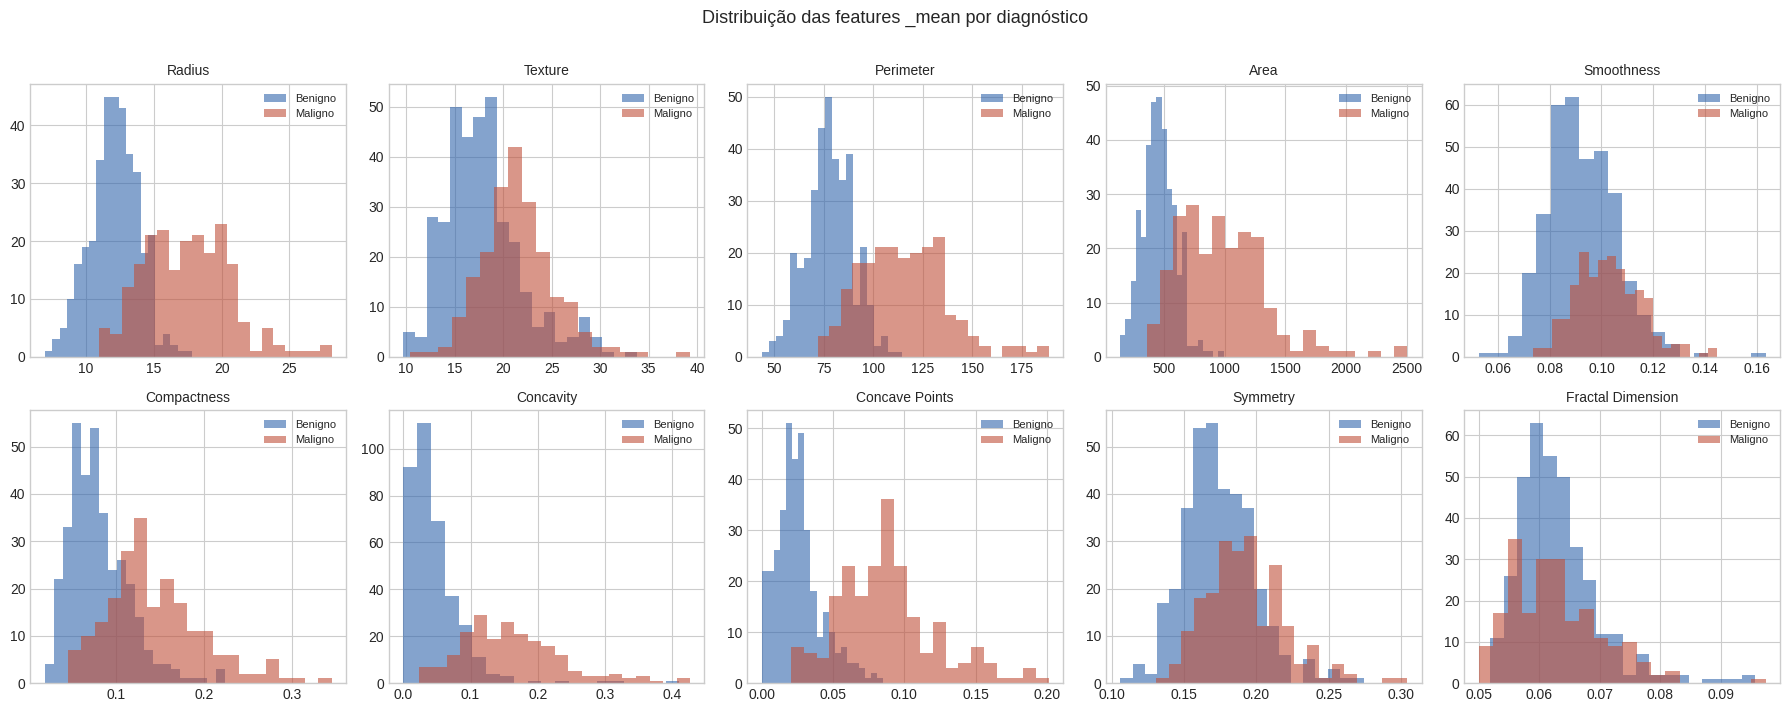

In [ ]:
mean_features = [c for c in df.columns if c.endswith('_mean')]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(mean_features):
    for diag, color, label in [('B', '#3266ad', 'Benigno'), ('M', '#c0503a', 'Maligno')]:
        axes[i].hist(df[df['diagnosis'] == diag][feat], bins=20,
                     alpha=0.6, color=color, label=label, edgecolor='none')
    axes[i].set_title(feat.replace('_mean', '').replace('_', ' ').title(), fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribuição das features _mean por diagnóstico', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# EDA adicional: violin plots e pairplot das principais features _mean
selected_mean = mean_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(selected_mean):
    sns.violinplot(x='diagnosis', y=feat, data=df, palette=['#3266ad', '#c0503a'], ax=axes[i])
    axes[i].set_title(feat)
plt.tight_layout()
plt.show()

# Pairplot (amostrado para acelerar a renderização)
sample_df = df.sample(n=min(300, len(df)), random_state=42)
sns.pairplot(sample_df, vars=selected_mean, hue='diagnosis',
             palette={0: '#3266ad', 1: '#c0503a'}, diag_kind='kde',
             plot_kws={'alpha':0.6, 's':30})
plt.suptitle('Pairplot das principais features _mean (amostra)', y=1.02)
plt.show()

## Pré-processamento e seleção de features

In [ ]:
# Drop da coluna 'Unnamed: 32' e 'id' para mapeamento da coluna 'diagnosis'
columns_to_drop = ['Unnamed: 32','id']
df.drop(columns=columns_to_drop, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Metricas de correlação
correlation_matrix = df.corr()['diagnosis'].sort_values(ascending=False)

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Métricas de seleção de features (SelectKBest)
selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X, y)
scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

resultado = pd.concat([correlation_matrix.drop(['diagnosis']), scores], axis=1)
resultado.columns = ['Corr', 'KBest']
resultado = resultado.sort_values('KBest', ascending=False)

print('=== CORRELAÇÃO vs KBEST ===')
print(resultado)

=== CORRELAÇÃO vs KBEST ===
                             Corr       KBest
concave points_worst     0.793566  964.385393
perimeter_worst          0.782914  897.944219
concave points_mean      0.776614  861.676020
radius_worst             0.776454  860.781707
perimeter_mean           0.742636  697.235272
area_worst               0.733825  661.600206
radius_mean              0.730029  646.981021
area_mean                0.708984  573.060747
concavity_mean           0.696360  533.793126
concavity_worst          0.659610  436.691939
compactness_mean         0.596534  313.233079
compactness_worst        0.590998  304.341063
radius_se                0.567134  268.840327
perimeter_se             0.556141  253.897392
area_se                  0.548236  243.651586
texture_worst            0.456903  149.596905
smoothness_worst         0.421465  122.472880
symmetry_worst           0.416294  118.860232
texture_mean             0.415185  118.096059
concave points_se        0.408042  113.262760
smooth

### Matriz de correlação

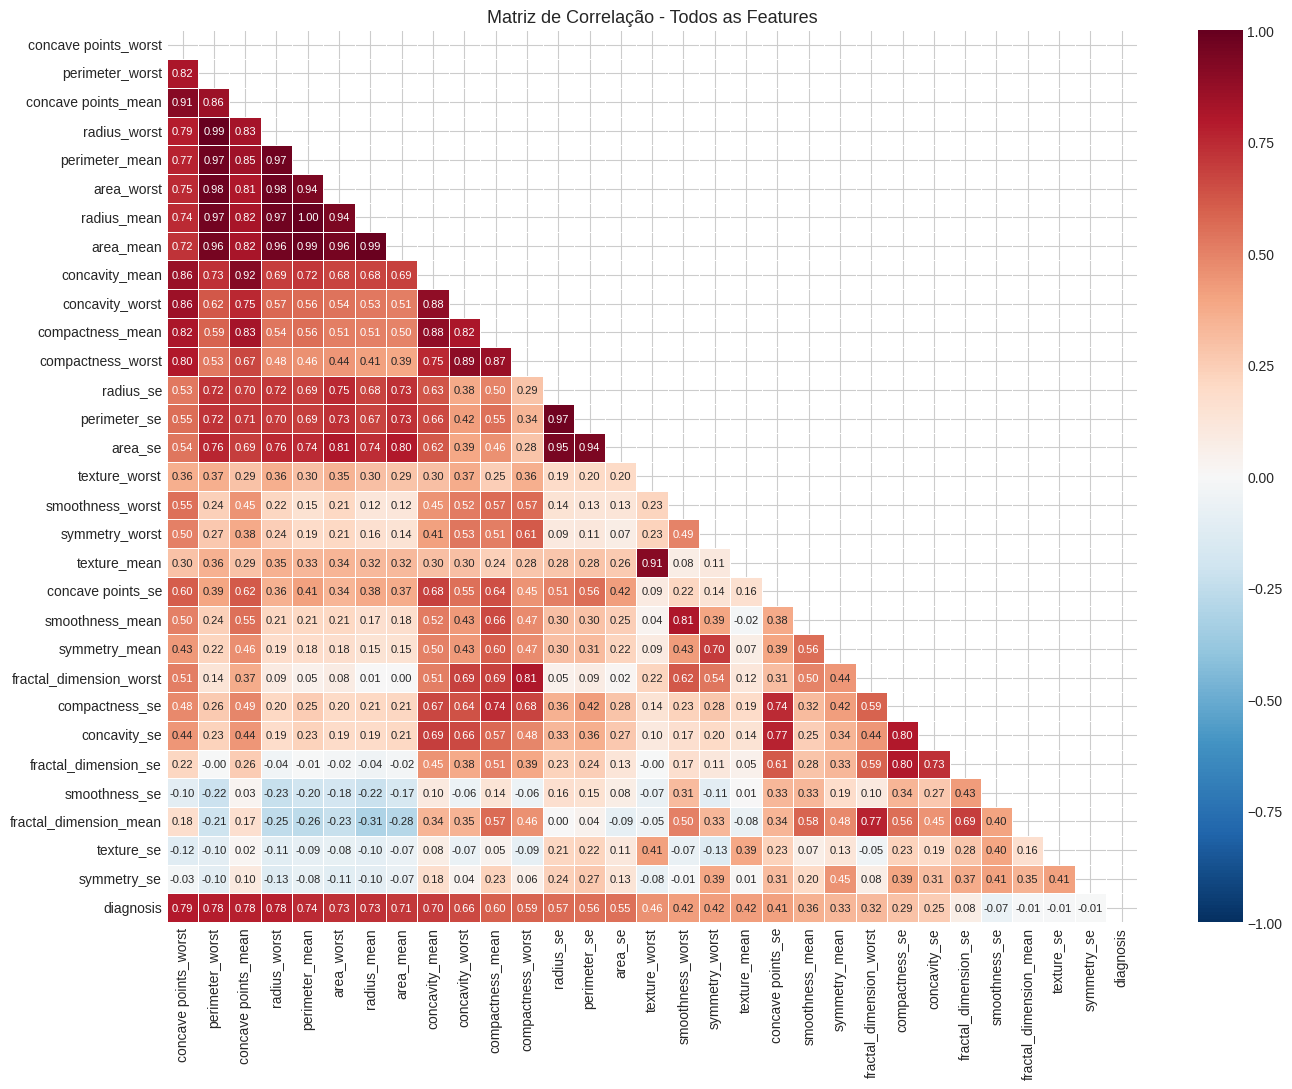

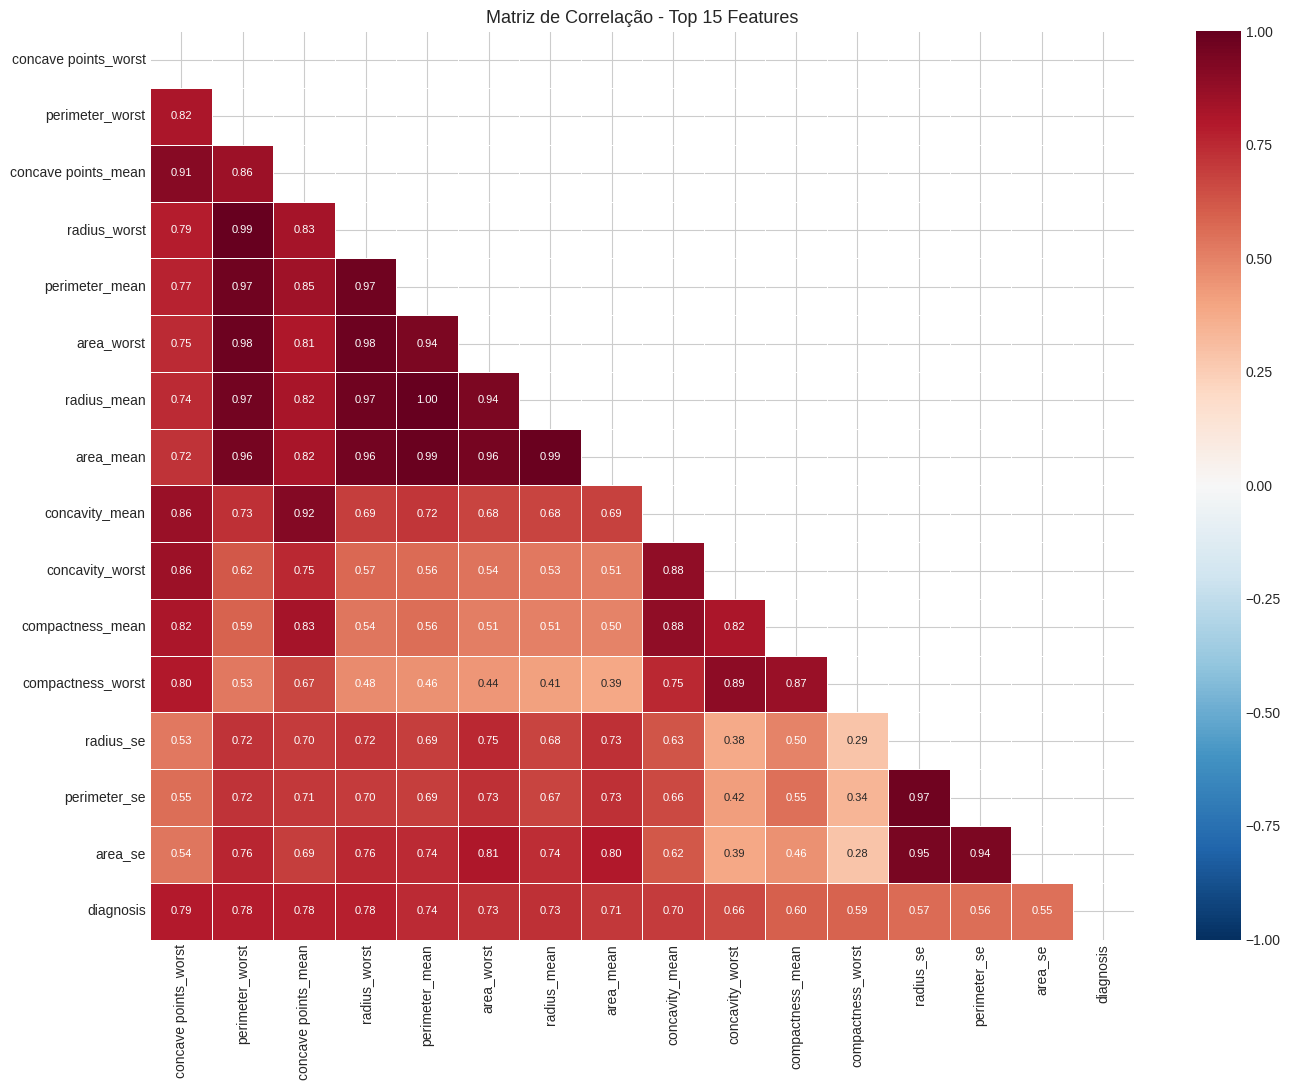

In [ ]:
top_features = resultado.index.tolist()
corr_matrix = df[top_features + ['diagnosis']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlação - Todos as Features', fontsize=13)
plt.tight_layout()
plt.show()

# Foco nas top 15 features
top_features = resultado.head(15).index.tolist()
corr_matrix = df[top_features + ['diagnosis']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlação - Top 15 Features', fontsize=13)
plt.tight_layout()
plt.show()

### Comparativo: features _mean vs _worst

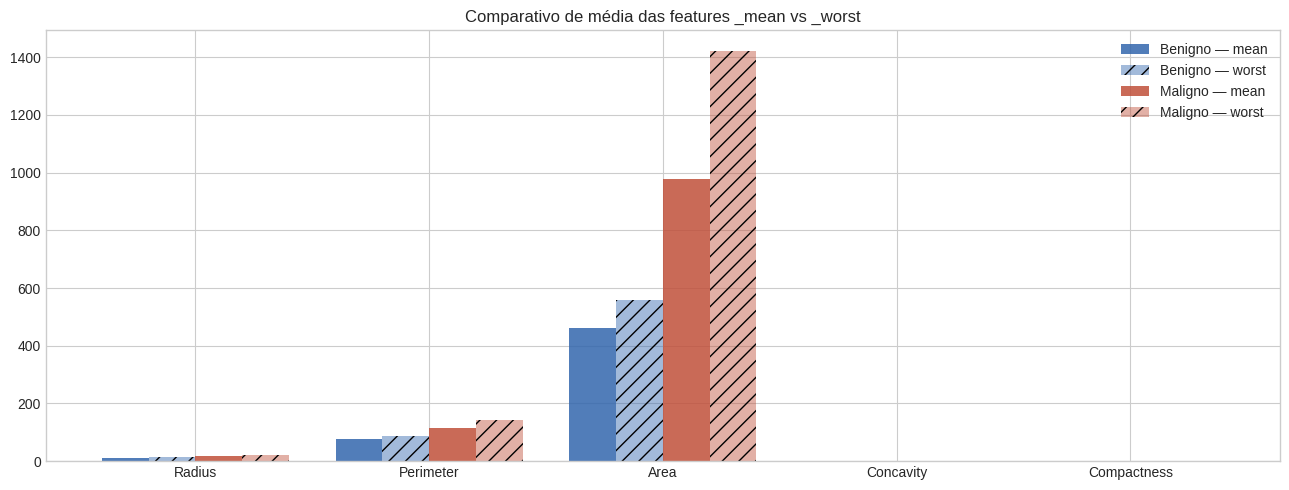

In [ ]:
base_names = ['radius', 'perimeter', 'area', 'concavity', 'compactness']

# Benigno
mean_vals_b  = [df[df['diagnosis']==0][f'{n}_mean'].mean()  for n in base_names]
worst_vals_b = [df[df['diagnosis']==0][f'{n}_worst'].mean() for n in base_names]

# Maligno
mean_vals_m  = [df[df['diagnosis']==1][f'{n}_mean'].mean()  for n in base_names]
worst_vals_m = [df[df['diagnosis']==1][f'{n}_worst'].mean() for n in base_names]

x = np.arange(len(base_names))
w = 0.2

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 1.5*w, mean_vals_b,  w, label='Benigno — mean',  color='#3266ad', alpha=0.85)
ax.bar(x - 0.5*w, worst_vals_b, w, label='Benigno — worst', color='#3266ad', alpha=0.45, hatch='//')
ax.bar(x + 0.5*w, mean_vals_m,  w, label='Maligno — mean',  color='#c0503a', alpha=0.85)
ax.bar(x + 1.5*w, worst_vals_m, w, label='Maligno — worst', color='#c0503a', alpha=0.45, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels([n.capitalize() for n in base_names])
ax.set_title('Comparativo de média das features _mean vs _worst')
ax.legend()
plt.tight_layout()
plt.show()

### PCA - visualização 2D

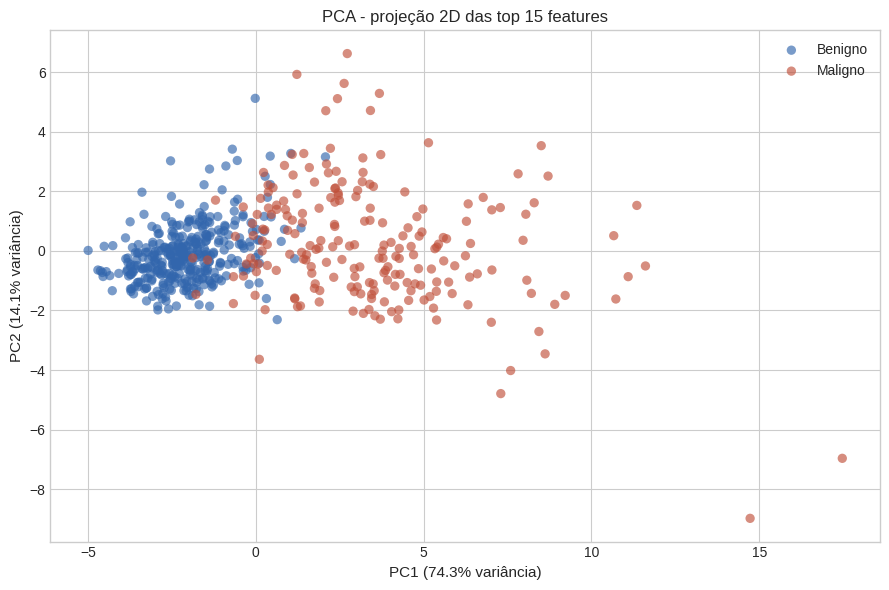

In [ ]:
X_top = df[top_features]
X_scaled_pca = StandardScaler().fit_transform(X_top)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_pca)

fig, ax = plt.subplots(figsize=(9, 6))
colors = {0: '#3266ad', 1: '#c0503a'}
labels_map = {0: 'Benigno', 1: 'Maligno'}
for diag in [0, 1]:
    mask = y == diag
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[diag], label=labels_map[diag],
               alpha=0.65, edgecolors='none', s=45)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)', fontsize=11)
ax.set_title('PCA - projeção 2D das top 15 features')
ax.legend()
plt.tight_layout()
plt.show()

## Divisão dos dados paara treinamento, Teste e Validação

In [ ]:
X = df[top_features]

# 40% treino / 60% restante
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.60, random_state=42, stratify=y
)
# 30% val / 30% teste  (50/50 do restante)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('=== DIVISÃO DOS DADOS ===')
print(f'Treino:    {len(X_train):>4} amostras  '
      f'(B={sum(y_train==0)}, M={sum(y_train==1)})')
print(f'Validação: {len(X_val):>4} amostras  '
      f'(B={sum(y_val==0)}, M={sum(y_val==1)})')
print(f'Teste:     {len(X_test):>4} amostras  '
      f'(B={sum(y_test==0)}, M={sum(y_test==1)})')

# StandardScaler (LR e SVM) — fit apenas no treino
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Treinar modelos
lr  = LogisticRegression(max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(probability=True, random_state=42)

lr.fit(X_train_sc, y_train)   # com scaler
rf.fit(X_train, y_train)      # sem scaler
svm.fit(X_train_sc, y_train)  # com scaler

print('\nModelos treinados com sucesso!')

=== DIVISÃO DOS DADOS ===
Treino:     227 amostras  (B=142, M=85)
Validação:  171 amostras  (B=107, M=64)
Teste:      171 amostras  (B=108, M=63)

Modelos treinados com sucesso!


### Validação Cruzada Estratificada (StratifiedKFold)

Usamos `StratifiedKFold` para preservar a proporção das classes em cada fold. A seguir executamos uma validação cruzada de 5 folds e reportamos as métricas médias (accuracy, precision, recall, F1 e AUC) para cada modelo.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

models = [('Logistic Regression', lr), ('Random Forest', rf), ('SVM', svm)]
cv_results = {}
for name, model in models:
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    summary = {metric: (scores[f'test_{metric}'].mean(), scores[f'test_{metric}'].std()) for metric in scoring}
    cv_results[name] = summary
    print(f'--- {name} (5-fold Stratified CV) ---')
    for metric, (mu, sd) in summary.items():
        print(f'{metric:>8}: {mu:.4f} ± {sd:.4f}')
    print()

## Avaliação dos Modelos

In [ ]:
models_info = [
    ('Logistic Regression', lr, X_train_sc, X_val_sc, X_test_sc),
    ('Random Forest', rf, X_train, X_val, X_test),
    ('SVM', svm, X_train_sc, X_val_sc, X_test_sc),
]

metrics_val  = []
metrics_test = []

for name, model, Xtr, Xv, Xte in models_info:
    # Validação
    yv_pred  = model.predict(Xv)
    yv_proba = model.predict_proba(Xv)[:, 1]
    metrics_val.append({
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_val, yv_pred),
        'Precision': precision_score(y_val, yv_pred),
        'Recall':    recall_score(y_val, yv_pred),
        'F1':        f1_score(y_val, yv_pred),
        'AUC':       roc_auc_score(y_val, yv_proba),
    })
    # Teste
    yt_pred  = model.predict(Xte)
    yt_proba = model.predict_proba(Xte)[:, 1]
    metrics_test.append({
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_test, yt_pred),
        'Precision': precision_score(y_test, yt_pred),
        'Recall':    recall_score(y_test, yt_pred),
        'F1':        f1_score(y_test, yt_pred),
        'AUC':       roc_auc_score(y_test, yt_proba),
    })

df_val  = pd.DataFrame(metrics_val).set_index('Modelo')
df_test = pd.DataFrame(metrics_test).set_index('Modelo')

print('=== MÉTRICAS — VALIDAÇÃO ===')
print(df_val.round(4).to_string())
print('\n=== MÉTRICAS — TESTE ===')
print(df_test.round(4).to_string())

=== MÉTRICAS — VALIDAÇÃO ===
                     Accuracy  Precision  Recall      F1     AUC
Modelo                                                          
Logistic Regression    0.9708     1.0000  0.9219  0.9593  0.9959
Random Forest          0.9591     0.9672  0.9219  0.9440  0.9960
SVM                    0.9591     0.9831  0.9062  0.9431  0.9968

=== MÉTRICAS — TESTE ===
                     Accuracy  Precision  Recall      F1     AUC
Modelo                                                          
Logistic Regression    0.9474     0.9655  0.8889  0.9256  0.9893
Random Forest          0.9415     0.9818  0.8571  0.9153  0.9854
SVM                    0.9298     1.0000  0.8095  0.8947  0.9888


### Gráfico de barras comparativo de métricas

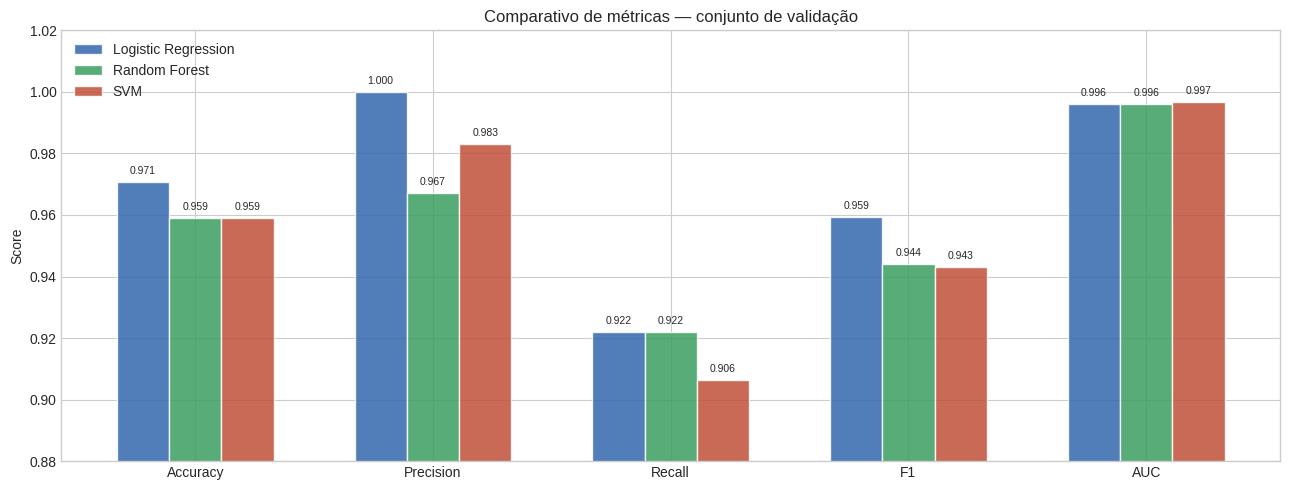

In [ ]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
model_names = df_val.index.tolist()
colors_m = ['#3266ad', '#3a9e5f', '#c0503a']

x = np.arange(len(metric_cols))
w = 0.22

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(model_names, colors_m)):
    vals = df_val.loc[name, metric_cols].values
    bars = ax.bar(x + (i-1)*w, vals, w, label=name,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_ylim(0.88, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_title('Comparativo de métricas — conjunto de validação')
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## Matrizes de confusão

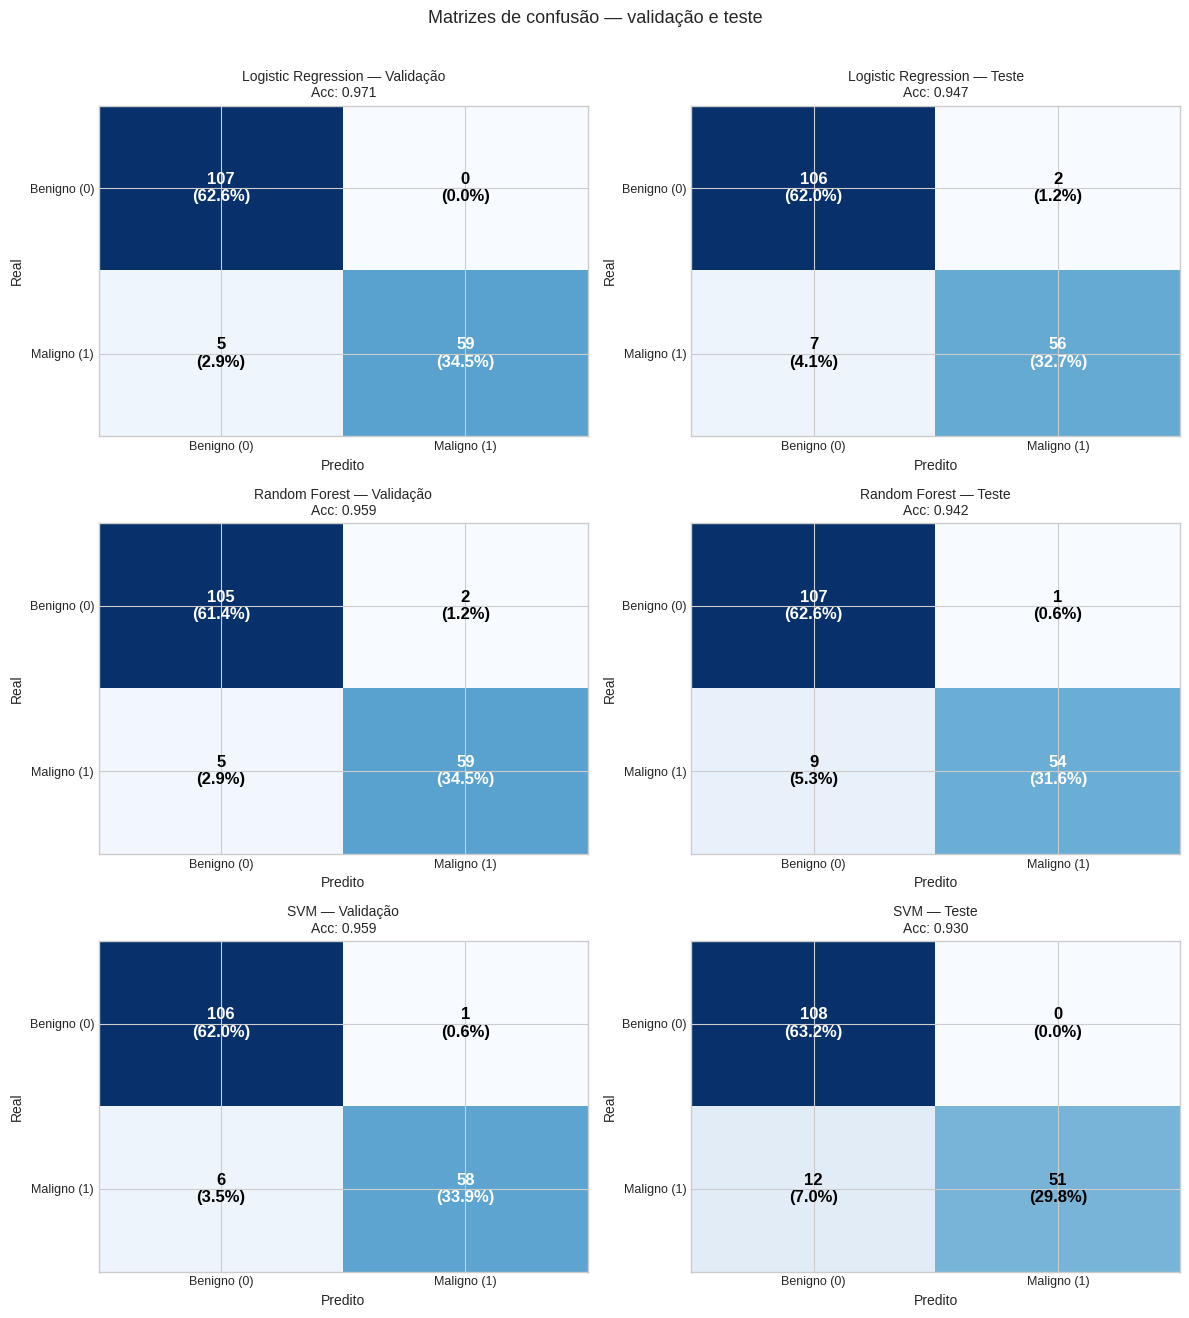

In [ ]:
def plot_confusion_matrices(models_info, y_val, y_test):
    fig, axes = plt.subplots(3, 2, figsize=(12, 13))
    class_names = ['Benigno (0)', 'Maligno (1)']

    for row, (name, model, Xtr, Xv, Xte) in enumerate(models_info):
        for col, (Xdata, ytrue, split_name) in enumerate([
            (Xv,  y_val,  'Validação'),
            (Xte, y_test, 'Teste')
        ]):
            ypred = model.predict(Xdata)
            cm = confusion_matrix(ytrue, ypred)
            ax = axes[row, col]

            # Heatmap
            im = ax.imshow(cm, cmap='Blues', aspect='auto')

            # Anotações
            for i in range(2):
                for j in range(2):
                    pct = cm[i, j] / cm.sum() * 100
                    color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
                    ax.text(j, i, f'{cm[i,j]}\n({pct:.1f}%)',
                            ha='center', va='center', color=color,
                            fontsize=12, fontweight='bold')

            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(class_names, fontsize=9)
            ax.set_yticklabels(class_names, fontsize=9)
            ax.set_xlabel('Predito', fontsize=10)
            ax.set_ylabel('Real', fontsize=10)
            acc = accuracy_score(ytrue, ypred)
            ax.set_title(f'{name} — {split_name}\nAcc: {acc:.3f}', fontsize=10)

    plt.suptitle('Matrizes de confusão — validação e teste', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(models_info, y_val, y_test)

## Curvas ROC / AUC

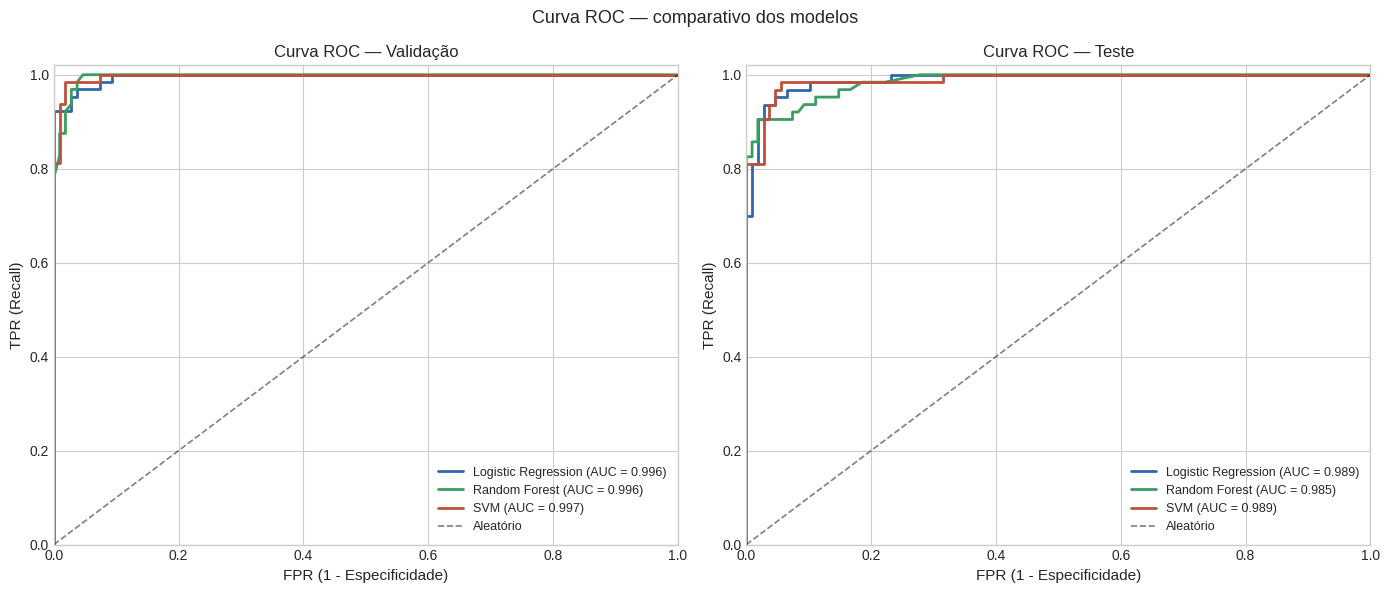

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (Xdata, ytrue, split_name) in zip(axes, [
    (None, y_val,  'Validação'),
    (None, y_test, 'Teste')
]):
    for (name, model, Xtr, Xv, Xte), color in zip(models_info, colors_m):
        Xdata = Xv if split_name == 'Validação' else Xte
        ytrue_local = y_val if split_name == 'Validação' else y_test
        yproba = model.predict_proba(Xdata)[:, 1]
        fpr, tpr, _ = roc_curve(ytrue_local, yproba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Aleatório')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('FPR (1 - Especificidade)', fontsize=11)
    ax.set_ylabel('TPR (Recall)', fontsize=11)
    ax.set_title(f'Curva ROC — {split_name}')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('Curva ROC — comparativo dos modelos', fontsize=13)
plt.tight_layout()
plt.show()

## Analise Detalhada dos modelos de Classificação

In [ ]:
for name, model, Xtr, Xv, Xte in models_info:
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    print('--- VALIDAÇÃO ---')
    print(classification_report(
        y_val, model.predict(Xv),
        target_names=['Benigno', 'Maligno'], digits=4
    ))

    print('--- TESTE ---')
    print(classification_report(
        y_test, model.predict(Xte),
        target_names=['Benigno', 'Maligno'], digits=4
    ))
    print()

  Logistic Regression
--- VALIDAÇÃO ---
              precision    recall  f1-score   support

     Benigno     0.9554    1.0000    0.9772       107
     Maligno     1.0000    0.9219    0.9593        64

    accuracy                         0.9708       171
   macro avg     0.9777    0.9609    0.9683       171
weighted avg     0.9721    0.9708    0.9705       171

--- TESTE ---
              precision    recall  f1-score   support

     Benigno     0.9381    0.9815    0.9593       108
     Maligno     0.9655    0.8889    0.9256        63

    accuracy                         0.9474       171
   macro avg     0.9518    0.9352    0.9424       171
weighted avg     0.9482    0.9474    0.9469       171


  Random Forest
--- VALIDAÇÃO ---
              precision    recall  f1-score   support

     Benigno     0.9545    0.9813    0.9677       107
     Maligno     0.9672    0.9219    0.9440        64

    accuracy                         0.9591       171
   macro avg     0.9609    0.9516    0.

## Tabela comparativa final

In [ ]:
print('=== TABELA COMPARATIVA — VALIDAÇÃO ===')
print(df_val.round(4).to_string())

print('\n=== TABELA COMPARATIVA — TESTE ===')
print(df_test.round(4).to_string())

print('\n=== MELHOR MODELO POR MÉTRICA (VALIDAÇÃO) ===')
for col in df_val.columns:
    best = df_val[col].idxmax()
    print(f'{col:>12}: {best} ({df_val.loc[best, col]:.4f})')
        {
            "cell_type": "code",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Salvar modelo final e scaler com joblib para uso posterior no Streamlit",
                "import joblib",
                "from pathlib import Path",
                "",
                "model_dir = Path('model')",
                "model_dir.mkdir(parents=True, exist_ok=True)",
                "",
                "# Escolher melhor modelo pela métrica AUC no conjunto de validação",
                "best_model_name = df_val['AUC'].idxmax()",
                "models_map = {'Logistic Regression': lr, 'Random Forest': rf, 'SVM': svm}",
                "best_model = models_map[best_model_name]",
                "",
                "joblib.dump(best_model, model_dir / 'model_final.joblib')",
                "# Salvar scaler apenas se o modelo esperar dados padronizados",
                "if best_model_name in ['Logistic Regression', 'SVM']:",
                "    joblib.dump(scaler, model_dir / 'scaler.joblib')",
                "",
                "print(f'Modelo salvo: {best_model_name} -> {model_dir / \"model_final.joblib\"}')",
                "",
                "# Testar carregamento rápido do modelo salvo",
                "loaded = joblib.load(model_dir / 'model_final.joblib')",
                "sample_X = X_test.iloc[:5] if isinstance(X_test, pd.DataFrame) else X_test[:5]",
                "try:",
                "    if best_model_name in ['Logistic Regression', 'SVM']:",
                "        sample_X_sc = scaler.transform(sample_X)",
                "        preds = loaded.predict(sample_X_sc)",
                "    else:",
                "        preds = loaded.predict(sample_X)",
                "    print('Teste de carregamento OK. Predições exemplo:', preds)",
                "except Exception as e:",
                "    print('Aviso: erro ao testar predição com o modelo carregado:', e)"
            ]
        },

=== TABELA COMPARATIVA — VALIDAÇÃO ===
                     Accuracy  Precision  Recall      F1     AUC
Modelo                                                          
Logistic Regression    0.9708     1.0000  0.9219  0.9593  0.9959
Random Forest          0.9591     0.9672  0.9219  0.9440  0.9960
SVM                    0.9591     0.9831  0.9062  0.9431  0.9968

=== TABELA COMPARATIVA — TESTE ===
                     Accuracy  Precision  Recall      F1     AUC
Modelo                                                          
Logistic Regression    0.9474     0.9655  0.8889  0.9256  0.9893
Random Forest          0.9415     0.9818  0.8571  0.9153  0.9854
SVM                    0.9298     1.0000  0.8095  0.8947  0.9888

=== MELHOR MODELO POR MÉTRICA (VALIDAÇÃO) ===
    Accuracy: Logistic Regression (0.9708)
   Precision: Logistic Regression (1.0000)
      Recall: Logistic Regression (0.9219)
          F1: Logistic Regression (0.9593)
         AUC: SVM (0.9968)
